(affine_risk_prices)=
```{raw} html
<div id="qe-notebook-header" align="right" style="text-align:right;">
        <a href="https://quantecon.org/" title="quantecon.org">
                <img style="width:250px;display:inline;" width="250px" src="https://assets.quantecon.org/img/qe-menubar-logo.svg" alt="QuantEcon">
        </a>
</div>
```

# 资产价格的仿射模型

## 概述

本讲座描述了一类随机贴现因子的**仿射**或**指数二次型**模型，这类模型在实证金融中已被广泛使用。

这些模型在 {cite:t}`Ljungqvist2012` 的第 15 章中有所介绍。

这里讨论的模型采用了与 {cite:t}`hansen1983stochastic` 中时间可分的 CRRA 随机贴现因子不同的方法，后者在我们的 {doc}`配套讲座 <hansen_singleton_1983>` 中进行了研究。

CRRA 随机贴现因子为

$$
m_{t+1} = \exp\left(-r_t - \frac{1}{2}\sigma_c^2 \gamma^2 - \gamma\sigma_c\varepsilon_{t+1}\right)
$$

其中 $r_t = \rho + \gamma\mu - \frac{1}{2}\sigma_c^2\gamma^2$。

该模型断言，对总消费增长的随机部分 $\sigma_c\varepsilon_{t+1}$ 的暴露是*唯一*被定价的风险，是各资产预期回报之间差异的唯一来源。

这一设定的实证困难（股权溢价之谜、无风险利率之谜，以及 {doc}`advanced:doubts_or_variability` 中讨论的 Hansen-Jagannathan 边界）促使人们采用本讲座所描述的替代方法。

直白地说，本讲座将研究的模型宣告了卢卡斯资产定价模型的随机贴现因子的失败。

**仿射模型**保持 $\mathbb{E}(m_{t+1}R_{j,t+1}) = 1$，但将随机贴现因子与消费风险*分离*，从而也在很大程度上与宏观经济学分离。

相反，它

* 为 $m_{t+1}$ 指定了一个解析上易于处理的随机过程，并
* 利用应用于 $N$ 种资产的 $\mathbb{E}(m_{t+1}R_{j,t+1}) = 1$ 的过度识别约束，让数据揭示风险及其价格。

```{note}
包括 {cite}`Bansal_Yaron_2004` 和 {cite}`hansen2008consumption` 在内的研究者一直不太愿意放弃基于消费的随机贴现因子模型。
```

我们研究的关键应用包括：

1. *对风险资产定价*：风险价格和暴露如何决定超额回报。
2. *仿射期限结构模型*：债券收益率作为状态向量的仿射函数（{cite:t}`AngPiazzesi2003`）。
3. *风险中性概率*：定价方程的一种测度变换表示。
4. *扭曲信念*：当行为主体持有系统性偏差的预测时，重新解释风险价格估计（{cite:t}`piazzesi2015trend`）；另见 {doc}`advanced:risk_aversion_or_mistaken_beliefs`。

我们从以下导入开始：

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from collections import namedtuple
from numpy.linalg import eigvals

## 模型

### 状态动态与短期利率

该模型有两个部分。

*第一部分*是一个向量自回归，描述了经济状态和短期利率的演变：

```{math}
:label: eq_var

z_{t+1} = \mu + \phi z_t + C\varepsilon_{t+1}
```

```{math}
:label: eq_shortrate

r_t = \delta_0 + \delta_1^\top z_t
```

这里

* $\phi$ 是一个稳定的 $m \times m$ 矩阵，
* $C$ 是一个 $m \times m$ 矩阵，
* $\varepsilon_{t+1} \sim \mathcal{N}(0, I)$ 是一个独立同分布的 $m \times 1$ 随机向量，
* $z_t$ 是一个 $m \times 1$ 状态向量。

方程 {eq}`eq_shortrate` 表明，**短期利率** $r_t$，即单期无风险债权的净收益率，是状态 $z_t$ 的仿射函数。

*第二部分*是一个**风险价格**向量 $\lambda_t$ 及其相关的随机贴现因子 $m_{t+1}$：

```{math}
:label: eq_riskprices

\lambda_t = \lambda_0 + \lambda_z z_t
```

```{math}
:label: eq_sdf

\log(m_{t+1}) = -r_t - \frac{1}{2}\lambda_t^\top\lambda_t - \lambda_t^\top\varepsilon_{t+1}
```

这里 $\lambda_0$ 是 $m \times 1$，$\lambda_z$ 是 $m \times m$。

$\lambda_t$ 中乘以风险 $\varepsilon_{t+1}$ 相应分量的各项被称为**风险价格**，因为它们决定了对每个风险分量的暴露如何影响预期回报（如我们下面所示）。

由于 $\lambda_t$ 是 $z_t$ 的仿射函数，随机贴现因子 $m_{t+1}$ 是状态 $z_t$ 的**指数二次型**。

我们按如下方式实现模型的各部分。

In [2]:
AffineModel = namedtuple('AffineModel',
    ('μ', 'φ', 'C', 'δ_0', 'δ_1', 'λ_0', 'λ_z', 'm', 'φ_rn', 'μ_rn'))

def create_affine_model(μ, φ, C, δ_0, δ_1, λ_0, λ_z):
    """创建一个仿射期限结构模型。"""
    μ = np.asarray(μ, float)
    φ = np.asarray(φ, float)
    C = np.asarray(C, float)
    δ_1 = np.asarray(δ_1, float)
    λ_0, λ_z = np.asarray(λ_0, float), np.asarray(λ_z, float)
    return AffineModel(μ=μ, φ=φ, C=C, δ_0=float(δ_0), δ_1=δ_1,
                       λ_0=λ_0, λ_z=λ_z, m=len(μ),
                       φ_rn=φ - C @ λ_z, μ_rn=μ - C @ λ_0)

def simulate(model, z0, T, rng=None):
    """在 T 期内模拟 z_{t+1} = μ + φ z_t + C ε_{t+1}。"""
    if rng is None:
        rng = np.random.default_rng(42)
    Z = np.zeros((T + 1, model.m))
    Z[0] = z0
    for t in range(T):
        ε = rng.standard_normal(model.m)
        Z[t + 1] = model.μ + model.φ @ Z[t] + model.C @ ε
    return Z

def short_rate(model, z):
    """计算 r_t = δ_0 + δ_1^⊤ z_t。"""
    return model.δ_0 + model.δ_1 @ z

def risk_prices(model, z):
    """计算 λ_t = λ_0 + λ_z z_t。"""
    return model.λ_0 + model.λ_z @ z

### SDF 的性质

由于 $\lambda_t^\top\varepsilon_{t+1}$ 是条件正态的，因此有

$$
\mathbb{E}_t(m_{t+1}) = \exp(-r_t)
$$

以及

$$
\text{std}_t(m_{t+1}) \approx \| \lambda_t \|.
$$

```{exercise}
:label: arp_ex1

证明 {eq}`eq_sdf` 中定义的 SDF 满足

$$
\mathbb{E}_t(m_{t+1}) = \exp(-r_t)
$$

以及

$$
\text{std}_t(m_{t+1}) \approx \| \lambda_t \|
$$

其中 $\| \lambda_t \| = \sqrt{\lambda_t^\top\lambda_t}$ 表示风险价格向量的欧几里得范数。

对于第二个结果，使用对数正态方差公式以及对小的 $x$ 和 $r_t$ 的近似 $\exp(x) \approx 1 + x$ 和 $\exp(-r_t) \approx 1$。
```

```{solution-start} arp_ex1
:class: dropdown
```

由 {eq}`eq_sdf`，我们有

$$
m_{t+1} = \exp\left(-r_t - \frac{1}{2}\lambda_t^\top\lambda_t - \lambda_t^\top\varepsilon_{t+1}\right)
$$


由于 $-\lambda_t^\top \varepsilon_{t+1} \sim \mathcal{N}(0, \lambda_t^\top \lambda_t)$，我们有
$\mathbb{E}_t[\exp(-\lambda_t^\top \varepsilon_{t+1})] = \exp\left(\frac{1}{2}\lambda_t^\top \lambda_t\right)$。

因此，

$$
\mathbb{E}_t(m_{t+1}) = \exp(-r_t - \frac{1}{2}\lambda_t^\top\lambda_t) \mathbb{E}_t[\exp(-\lambda_t^\top\varepsilon_{t+1})] = \exp(-r_t)
$$

$m_{t+1}$ 是条件对数正态的，其中 $\log m_{t+1} \sim \mathcal{N}(-r_t-\frac{1}{2}\lambda_t^\top\lambda_t, \lambda_t^\top \lambda_t)$。

由对数正态方差公式
$\text{Var}(\exp(X)) = (\exp(\sigma^2) - 1) \exp(2\mu + \sigma^2)$（对于 $X \sim \mathcal{N}(\mu, \sigma^2)$），我们有

$$
\begin{aligned}
\text{Var}_t(m_{t+1}) &= (\exp(\lambda_t^\top \lambda_t) - 1) \exp(-2r_t) \\
&\approx \lambda_t^\top \lambda_t \exp(-2r_t)
\end{aligned}
$$

这是根据对小的 $x$ 的近似 $\exp(x) \approx 1 + x$ 得到的。

因此，

$$
\text{std}_t(m_{t+1}) \approx \| \lambda_t \| \exp(-r_t)
$$

对于小的 $r_t$，有 $\exp(-r_t) \approx 1$，我们得到

$$
\text{std}_t(m_{t+1}) \approx \| \lambda_t \|
$$

```{solution-end}
```

第一个方程确认 $r_t$ 是无风险单期债券的净收益率。

这就是为什么在指数二次型文献中 $r_t$ 被称为**短期利率**。

第二个方程表明，SDF 的条件标准差近似等于风险价格向量的大小，这是对整体**市场风险价格**的一种度量。

## 对风险资产定价

### 对数正态回报

考虑一种风险资产 $j$，其总回报具有对数正态的条件分布：

```{math}
:label: eq_return

R_{j,t+1} = \exp\left(\nu_t(j) - \frac{1}{2}\alpha_t(j)^\top\alpha_t(j) + \alpha_t(j)^\top\varepsilon_{t+1}\right)
```

其中**暴露向量**

```{math}
:label: eq_exposure

\alpha_t(j) = \alpha_0(j) + \alpha_z(j)\, z_t
```

这里 $\alpha_0(j)$ 是 $m \times 1$，$\alpha_z(j)$ 是 $m \times m$。

$\alpha_t(j)$ 的各分量表示 $\log R_{j,t+1}$ 对风险向量 $\varepsilon_{t+1}$ 相应分量的**暴露**。

设定 {eq}`eq_return` 蕴含 $\mathbb{E}_t R_{j,t+1} = \exp(\nu_t(j))$，
因此 $\nu_t(j)$ 是预期总回报的对数。

### 预期超额回报

将定价方程 $\mathbb{E}_t(m_{t+1}R_{j,t+1}) = 1$ 与对数正态随机变量的均值公式一起应用，得到

```{math}
:label: eq_excess

\nu_t(j) = r_t + \alpha_t(j)^\top\lambda_t
```

```{exercise}
:label: arp_ex2

使用 SDF {eq}`eq_sdf` 和回报设定 {eq}`eq_return`，推导预期超额回报公式 {eq}`eq_excess`：

$$
\nu_t(j) = r_t + \alpha_t(j)^\top\lambda_t
$$

*提示：* 从计算 $\log(m_{t+1} R_{j,t+1})$ 开始，识别其条件分布，并应用定价条件 $\mathbb{E}_t(m_{t+1}R_{j,t+1}) = 1$。
```

```{solution-start} arp_ex2
:class: dropdown
```

结合 {eq}`eq_sdf` 和 {eq}`eq_return`，我们得到

$$
\log(m_{t+1} R_{j,t+1}) = -r_t + \nu_t(j) - \frac{1}{2}\lambda_t^\top\lambda_t - \frac{1}{2}\alpha_t(j)^\top\alpha_t(j) + (\alpha_t(j) - \lambda_t)^\top\varepsilon_{t+1}
$$

这是条件正态的，均值为 $\mu = -r_t + \nu_t(j) - \frac{1}{2}\lambda_t^\top\lambda_t - \frac{1}{2}\alpha_t(j)^\top\alpha_t(j)$，方差为 $\sigma^2 = (\alpha_t(j) - \lambda_t)^\top(\alpha_t(j) - \lambda_t)$。

由于对于 $X \sim \mathcal{N}(\mu, \sigma^2)$ 有 $\mathbb{E}_t[\exp(X)] = \exp(\mu + \frac{1}{2}\sigma^2)$，定价条件 $\mathbb{E}_t(m_{t+1}R_{j,t+1}) = 1$ 要求 $\mu + \frac{1}{2}\sigma^2 = 0$。

展开 $\frac{1}{2}\sigma^2 = \frac{1}{2}\alpha_t(j)^\top\alpha_t(j) - \alpha_t(j)^\top\lambda_t + \frac{1}{2}\lambda_t^\top\lambda_t$ 并加到 $\mu$ 上，$\frac{1}{2}\lambda_t^\top\lambda_t$ 和 $\frac{1}{2}\alpha_t(j)^\top\alpha_t(j)$ 项相互抵消，剩下

$$
-r_t + \nu_t(j) - \alpha_t(j)^\top\lambda_t = 0
$$

这给出了 {eq}`eq_excess`。

```{solution-end}
```

这是一个核心结果。

它表明：

> 资产 $j$ 上的对数预期总回报等于短期利率加上资产暴露向量 $\alpha_t(j)$ 与风险价格向量 $\lambda_t$ 的内积。

$\lambda_t$ 的每个分量对 $\varepsilon_{t+1}$ 的相应分量进行定价。

对具有较大风险价格的风险分量有大量载荷的资产会获得相应较高的预期回报。

## 收益率的仿射期限结构

最重要的应用之一是 {cite:t}`AngPiazzesi2003` 研究的**仿射期限结构模型**。

### 债券价格

设 $p_t(n)$ 为在时刻 $t$ 到期于 $t + n$ 的无风险纯贴现债券（支付一单位消费）的价格。

从 $t$ 到 $t+1$ 持有一个 $(n+1)$ 期债券的单期总回报为

$$
R_{t+1} = \frac{p_{t+1}(n)}{p_t(n+1)}
$$

定价方程 $\mathbb{E}_t(m_{t+1}R_{t+1}) = 1$ 蕴含

```{math}
:label: eq_bondrecur

p_t(n+1) = \mathbb{E}_t\bigl(m_{t+1}\,p_{t+1}(n)\bigr)
```

初始条件为

$$
p_t(1) = \mathbb{E}_t(m_{t+1}) = \exp(-r_t) = \exp(-\delta_0 - \delta_1^\top z_t).
$$

### 指数仿射价格

递归 {eq}`eq_bondrecur` 有一个**指数仿射**解：

```{math}
:label: eq_bondprice

p_t(n) = \exp \bigl(\bar A_n + \bar B_n^\top z_t\bigr)
```

其中标量 $\bar A_n$ 和 $m \times 1$ 向量 $\bar B_n$ 满足**黎卡提差分方程**

```{math}
:label: eq_riccati_a

\bar A_{n+1} = \bar A_n + \bar B_n^\top(\mu - C\lambda_0) + \frac{1}{2}\bar B_n^\top CC^\top\bar B_n - \delta_0
```

```{math}
:label: eq_riccati_b

\bar B_{n+1}^\top = \bar B_n^\top(\phi - C\lambda_z) - \delta_1^\top
```

初始条件为 $\bar A_1 = -\delta_0$ 和 $\bar B_1 = -\delta_1$。

```{exercise}
:label: arp_ex3

通过将猜想的债券价格 {eq}`eq_bondprice` 代入定价递归 {eq}`eq_bondrecur` 并匹配系数，推导黎卡提差分方程 {eq}`eq_riccati_a` 和 {eq}`eq_riccati_b`。

*提示：* 将 $p_{t+1}(n) = \exp(\bar A_n + \bar B_n^\top z_{t+1})$ 和
{eq}`eq_sdf` 中的 $\log m_{t+1}$ 代入 {eq}`eq_bondrecur`。

使用状态动态 {eq}`eq_var` 将 $z_{t+1}$ 用 $z_t$ 和
$\varepsilon_{t+1}$ 表示，然后使用对数正态矩生成函数求条件期望。
```

```{solution-start} arp_ex3
:class: dropdown
```

我们要证明，如果 $p_t(n) = \exp(\bar A_n + \bar B_n^\top z_t)$，
那么递归 $p_t(n+1) = \mathbb{E}_t(m_{t+1}\, p_{t+1}(n))$ 得到
$p_t(n+1) = \exp(\bar A_{n+1} + \bar B_{n+1}^\top z_t)$，其中
$\bar A_{n+1}$ 和 $\bar B_{n+1}$ 由 {eq}`eq_riccati_a` 和
{eq}`eq_riccati_b` 给出。


由 {eq}`eq_sdf` 和 {eq}`eq_bondprice`，

$$
\log(m_{t+1}\, p_{t+1}(n)) = -r_t - \frac{1}{2}\lambda_t^\top\lambda_t - \lambda_t^\top\varepsilon_{t+1} + \bar A_n + \bar B_n^\top z_{t+1}
$$

代入 {eq}`eq_var` 中的 $z_{t+1} = \mu + \phi z_t + C\varepsilon_{t+1}$
和 {eq}`eq_shortrate` 中的 $r_t = \delta_0 + \delta_1^\top z_t$，得到

$$
\log(m_{t+1}\, p_{t+1}(n)) = \bar A_n + \bar B_n^\top\mu - \delta_0 + (\bar B_n^\top\phi - \delta_1^\top) z_t - \frac{1}{2}\lambda_t^\top\lambda_t + (\bar B_n^\top C - \lambda_t^\top)\varepsilon_{t+1}
$$


由于 $\varepsilon_{t+1} \sim \mathcal{N}(0, I)$，将指数写成 $a + b^\top\varepsilon_{t+1}$ 的形式，其中
$b = C^\top \bar B_n - \lambda_t$，我们有

$$
\mathbb{E}_t[\exp(a + b^\top\varepsilon_{t+1})] = \exp\left(a + \frac{1}{2}b^\top b\right)
$$

计算 $\frac{1}{2}b^\top b$：

$$
\frac{1}{2}(\bar B_n^\top C - \lambda_t^\top)(\bar B_n^\top C - \lambda_t^\top)^\top = \frac{1}{2}\bar B_n^\top CC^\top \bar B_n - \bar B_n^\top C\lambda_t + \frac{1}{2}\lambda_t^\top\lambda_t
$$

$\frac{1}{2}\lambda_t^\top\lambda_t$ 与已经在 $a$ 中的 $-\frac{1}{2}\lambda_t^\top\lambda_t$ 相互抵消，并且 $-\bar B_n^\top C\lambda_t = -\bar B_n^\top C(\lambda_0 + \lambda_z z_t)$。


$$
\log p_t(n+1) = \underbrace{\bar A_n + \bar B_n^\top(\mu - C\lambda_0) + \frac{1}{2}\bar B_n^\top CC^\top \bar B_n - \delta_0}_{\bar A_{n+1}} + \underbrace{(\bar B_n^\top(\phi - C\lambda_z) - \delta_1^\top)}_{\bar B_{n+1}^\top} z_t
$$

匹配常数项和 $z_t$ 上的系数，得到黎卡提
方程 {eq}`eq_riccati_a` 和 {eq}`eq_riccati_b`。

令 $n = 0$，其中 $p_t(1) = \exp(-r_t) = \exp(-\delta_0 - \delta_1^\top z_t)$，得到 $\bar A_1 = -\delta_0$ 和 $\bar B_1 = -\delta_1$。

```{solution-end}
```

### 收益率

$n$ 期债券的**到期收益率**是一个常数利率 $y$，
以该利率将面值贴现可得到观察到的价格，
即 $p_t(n) = e^{-n\,y}$。

对 $y$ 求解得到

$$
y_t(n) = -\frac{\log p_t(n)}{n}
$$

代入 {eq}`eq_bondprice` 得到

```{math}
:label: eq_yield

y_t(n) = A_n + B_n^\top z_t
```

其中 $A_n = -\bar A_n / n$，$B_n = -\bar B_n / n$。

*收益率是状态向量 $z_t$ 的仿射函数。*

这是仿射期限结构模型的定义性质。

现在我们实现债券定价公式 {eq}`eq_riccati_a`、{eq}`eq_riccati_b`
和 {eq}`eq_yield`。

In [3]:
def bond_coefficients(model, n_max):
    """计算 n = 1, ..., n_max 的 (A_bar_n, B_bar_n)。"""
    A_bar = np.zeros(n_max + 1)
    B_bar = np.zeros((n_max + 1, model.m))
    A_bar[1], B_bar[1] = -model.δ_0, -model.δ_1
    CC = model.C @ model.C.T
    for n in range(1, n_max):
        Bn = B_bar[n]
        A_bar[n + 1] = (A_bar[n] + Bn @ model.μ_rn
                       + 0.5 * Bn @ CC @ Bn
                       - model.δ_0)
        B_bar[n + 1] = model.φ_rn.T @ Bn - model.δ_1
    return A_bar, B_bar

def compute_yields(model, z, n_max):
    """计算 n = 1, ..., n_max 的收益率曲线 y_t(n)。"""
    A_bar, B_bar = bond_coefficients(model, n_max)
    return np.array([(-A_bar[n] - B_bar[n] @ z) / n
                     for n in range(1, n_max + 1)])

def bond_prices(model, z, n_max):
    """计算 n = 1, ..., n_max 的债券价格 p_t(n)。"""
    A_bar, B_bar = bond_coefficients(model, n_max)
    return np.array([np.exp(A_bar[n] + B_bar[n] @ z)
                     for n in range(1, n_max + 1)])

### 单因子高斯示例

为了建立直觉，我们从单因子（$m=1$）高斯模型开始。

当 $m = 1$ 时，状态 $z_t$ 遵循 AR(1) 过程
$z_{t+1} = \mu + \phi z_t + C\varepsilon_{t+1}$。

$z_t$ 的无条件标准差
为 $\sigma_z = C / \sqrt{1 - \phi^2}$，它通过 $r_t = \delta_0 + \delta_1 z_t$ 决定
模型所生成的短期利率的范围。

In [4]:
# 单因子高斯模型（季度）
μ      = np.array([0.0])
φ      = np.array([[0.95]])
C      = np.array([[1.0]])
δ_0    = 0.01                  # 1%/季度 ≈ 4% 年化
δ_1    = np.array([0.001])
λ_0    = np.array([-0.05])
λ_z    = np.array([[-0.01]])

model_1f = create_affine_model(μ, φ, C, δ_0, δ_1, λ_0, λ_z)

### 收益率曲线形状

我们计算在一系列短期利率状态 $z_t$ 下的收益率曲线 $y_t(n)$。

findfont: Failed to find font weight normal, now using 600.
findfont: Failed to find font weight normal, now using 600.
findfont: Failed to find font weight normal, now using 600.


findfont: Failed to find font weight normal, now using 600.


findfont: Failed to find font weight normal, now using 600.


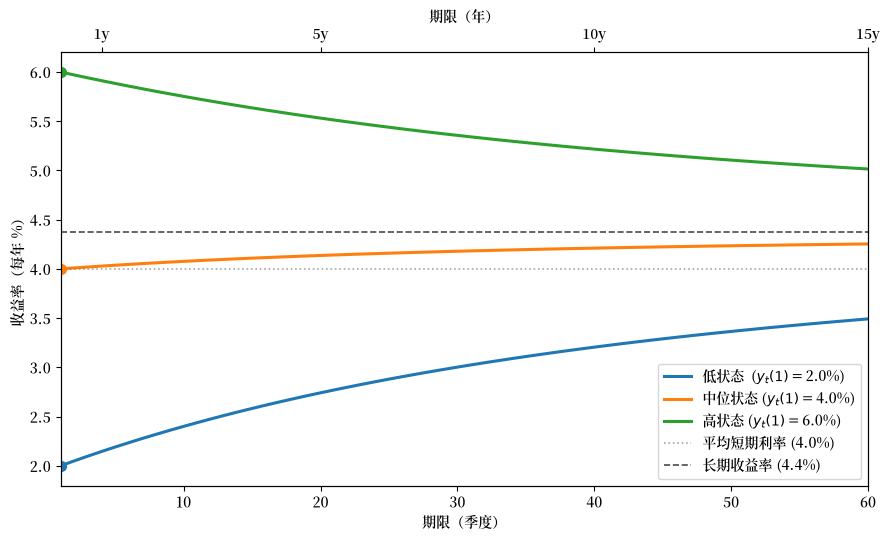

In [5]:
import matplotlib as mpl  # i18n
FONTPATH = "fonts/SourceHanSerifSC-SemiBold.otf"  # i18n
mpl.font_manager.fontManager.addfont(FONTPATH)  # i18n
mpl.rcParams['font.family'] = ['Source Han Serif SC', 'DejaVu Sans']  # i18n
n_max_1f = 60
maturities_1f = np.arange(1, n_max_1f + 1)

z_low  = np.array([-5.0])
z_mid  = np.array([0.0])
z_high = np.array([5.0])

fig, ax = plt.subplots(figsize=(9, 5.5))

r_low = short_rate(model_1f, z_low) * 4 * 100
r_mid = short_rate(model_1f, z_mid) * 4 * 100
r_high = short_rate(model_1f, z_high) * 4 * 100

for z, label in [
    (z_low,  f"低状态  ($y_t(1) = ${r_low:.1f}%)"),
    (z_mid,  f"中位状态 ($y_t(1) = ${r_mid:.1f}%)"),
    (z_high, f"高状态 ($y_t(1) = ${r_high:.1f}%)"),
]:
    y = compute_yields(model_1f, z, n_max_1f) * 4 * 100
    line, = ax.plot(maturities_1f, y, lw=2.2, label=label)
    ax.plot(1, y[0], 'o', color=line.get_color(), ms=7, zorder=5)

r_bar = short_rate(model_1f, np.array([0.0])) * 4 * 100
ax.axhline(r_bar, color='grey', ls=':', lw=1.2, alpha=0.7,
           label=f"平均短期利率 ({r_bar:.1f}%)")

# 长期收益率：B_bar_n 收敛，因此 y_inf = lim -A_bar_n / n
φ_Cλ = (model_1f.φ_rn)[0, 0]          # φ - Cλ_z（标量）
B_inf = -model_1f.δ_1[0] / (1 - φ_Cλ) # B 递归的不动点
A_increment = (B_inf * model_1f.μ_rn[0]
               + 0.5 * B_inf**2 * (model_1f.C @ model_1f.C.T)[0, 0]
               - model_1f.δ_0)
y_inf = -A_increment * 4 * 100         # 年化 %
ax.axhline(y_inf, color='black', ls='--', lw=1.2, alpha=0.7,
           label=f"长期收益率 ({y_inf:.1f}%)")

ax.set_xlabel("期限（季度）")
ax.set_ylabel("收益率（每年 %）")
ax.legend(fontsize=10, loc='best')
ax.set_xlim(1, n_max_1f)

ax2 = ax.twiny()
ax2.set_xlim(ax.get_xlim())
year_ticks = [4, 20, 40, 60]
ax2.set_xticks(year_ticks)
ax2.set_xticklabels([f"{t/4:.0f}y" for t in year_ticks])
ax2.set_xlabel("期限（年）")

plt.tight_layout()
plt.show()

当短期利率较低时，收益率曲线是
向上倾斜的，而当短期利率较高时，它是向下倾斜的。

所有三条曲线在长期限处收敛到同一个长期收益率 $y_\infty$，
并且长期收益率位于平均短期利率
$\delta_0$ 之上。

````{exercise}
:label: arp_ex4

证明长期收益率满足

```{math}
:label: eq_y_inf

y_\infty
  = \delta_0
  - \bar B_\infty^\top(\mu - C\lambda_0)
  - \tfrac{1}{2}\bar B_\infty^\top CC^\top \bar B_\infty
```

其中 $\bar B_\infty = -(I - (\phi - C\lambda_z)^\top)^{-1} \delta_1$
是递归 {eq}`eq_riccati_b` 的不动点。

然后解释为什么在这种参数化下 $y_\infty > \delta_0$。

*提示：* 使用 {eq}`eq_yield` 和黎卡提方程
{eq}`eq_riccati_a`--{eq}`eq_riccati_b`。对于不等式，分别考虑
每个被减去的项。
````

```{solution-start} arp_ex4
:class: dropdown
```


递归 {eq}`eq_riccati_b` 是一个线性差分方程 $\bar B_{n+1} = (\phi - C\lambda_z)^\top \bar B_n - \delta_1$。

当 $\phi - C\lambda_z$ 的特征值在单位圆内时，$\bar B_n$ 收敛到 $\bar B_\infty = -(I - (\phi - C\lambda_z)^\top)^{-1} \delta_1$。

由于 $\bar B_\infty$ 是有限的，在 {eq}`eq_yield` 中 $\bar B_n^\top z_t / n \to 0$，因此无论 $z_t$ 为何，$y_t(n) \to \lim_{n\to\infty} -\bar A_n / n$。

要找到这个极限，写 $\bar A_n = \bar A_1 + \sum_{k=1}^{n-1}(\bar A_{k+1} - \bar A_k)$。

根据 {eq}`eq_riccati_a`，每个增量取决于 $\bar B_k$，它收敛到 $\bar B_\infty$，因此增量收敛到 $L \equiv \bar B_\infty^\top(\mu - C\lambda_0) + \tfrac{1}{2}\bar B_\infty^\top CC^\top \bar B_\infty - \delta_0$。

因此 $\bar A_n / n \to L$，$y_\infty = -L$，得到 {eq}`eq_y_inf`。

要理解为什么 $y_\infty > \delta_0$，注意在这种参数化下 {eq}`eq_y_inf` 中的两个被减去的项符号相反。

二次项 $\tfrac{1}{2}\bar B_\infty^\top CC^\top \bar B_\infty = \tfrac{1}{2}\|C^\top \bar B_\infty\|^2 \geq 0$ 总是成立。

这是来自詹森不等式的**凸性效应**，它将 $y_\infty$ 推低到 $\delta_0$ 以下。

线性项 $\bar B_\infty^\top(\mu - C\lambda_0)$ 是负的，因为 $\bar B_\infty < 0$（由于 $\delta_1 > 0$）而 $\mu - C\lambda_0 > 0$（由于 $\lambda_0 < 0$）。减去这个负量将 $y_\infty$ 提升到 $\delta_0$ 之上。

这是**风险溢价效应**：正的期限溢价将平均收益率曲线向上倾斜。

在这种参数化下，风险溢价效应主导了凸性效应，因此 $y_\infty > \delta_0$。

```{solution-end}
```


让我们也模拟一下短期利率路径：

findfont: Failed to find font weight normal, now using 600.


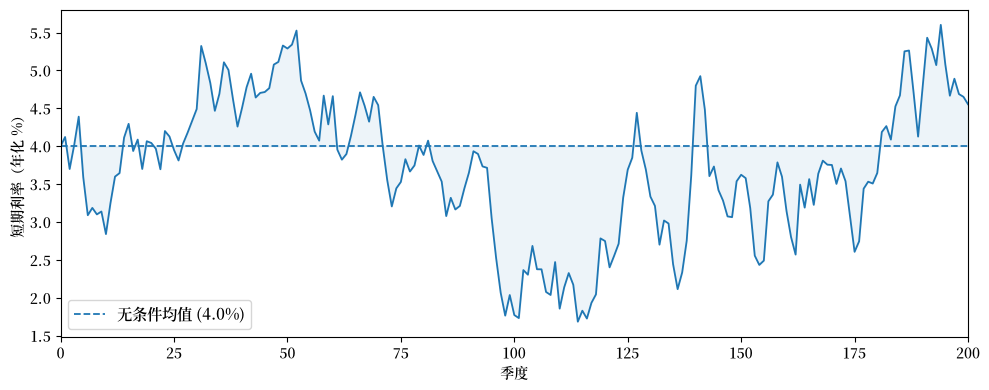

In [6]:
T = 200
Z = simulate(model_1f, np.array([0.0]), T)
short_rates = np.array([short_rate(model_1f, Z[t]) * 4 * 100
                        for t in range(T + 1)])
r_bar_pct = short_rate(model_1f, np.array([0.0])) * 4 * 100

fig, ax = plt.subplots(figsize=(10, 4))
quarters = np.arange(T + 1)
line, = ax.plot(quarters, short_rates, lw=1.3)
ax.axhline(r_bar_pct, ls="--", lw=1.3,
           label=f"无条件均值 ({r_bar_pct:.1f}%)")
ax.fill_between(quarters, short_rates, r_bar_pct,
                alpha=0.08, color=line.get_color())
ax.set_xlabel("季度")
ax.set_ylabel("短期利率（年化 %）")
ax.set_xlim(0, T)
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

### 双因子模型

为了匹配更丰富的收益率曲线动态，从业者通常使用 $m \geq 2$
个因子。

现在我们引入一个双因子设定，状态为
$z_t = (z_{1t},\, z_{2t})^\top$，其中

$$
z_{t+1} = \mu + \phi\, z_t + C\,\varepsilon_{t+1},
\qquad
\phi = \begin{pmatrix} 0.97 & -0.03 \\ 0 & 0.90 \end{pmatrix},
\qquad
C = I_2
$$

第一个因子 $z_{1t}$ 高度持续（$\phi_{11} = 0.97$），并
通过 $\delta_1$ 驱动短期利率的大部分变化，因此我们
将其解释为**水平**因子。

第二个因子 $z_{2t}$ 更快地均值回归（$\phi_{22} = 0.90$），并
以较小的载荷影响短期利率，捕捉收益率曲线的**斜率**。

非对角元素 $\phi_{12} = -0.03$ 允许水平因子
对当前斜率状态 $z_{2t}$ 做出响应。

短期利率为 $r_t = \delta_0 + \delta_1^\top z_t$，其中
$\delta_1 = (0.002,\; 0.001)^\top$，因此当两个因子为正时都会提高短期
利率，但水平因子的影响是斜率因子的两倍。

风险价格为 $\lambda_t = \lambda_0 + \lambda_z z_t$，其中
$\lambda_0 = (-0.01,\; -0.005)^\top$，
$\lambda_z = \text{diag}(-0.005,\, -0.003)$。

$\lambda_z$ 的负对角元素使得 $\phi - C\lambda_z$ 的特征值比 $\phi$
更大，因此在风险中性测度下状态更持续，收益率曲线在长期限处
对当前状态更敏感。

In [7]:
# 双因子模型：z = [水平, 斜率]
μ_2  = np.array([0.0,  0.0])
φ_2  = np.array([[0.97, -0.03],
                  [0.00,  0.90]])
C_2  = np.eye(2)
δ_0_2 = 0.01
δ_1_2 = np.array([0.002, 0.001])
λ_0_2 = np.array([-0.01, -0.005])
λ_z_2 = np.array([[-0.005, 0.0],
                   [ 0.0, -0.003]])

model_2f = create_affine_model(μ_2, φ_2, C_2, δ_0_2, δ_1_2, λ_0_2, λ_z_2)

print(f"φ 的特征值:       {eigvals(φ_2).real.round(4)}")
print(f"φ - Cλ_z 的特征值: {eigvals(model_2f.φ_rn).real.round(4)}")

φ 的特征值:       [0.97 0.9 ]
φ - Cλ_z 的特征值: [0.975 0.903]


这确认了 $\phi - C\lambda_z$ 的特征值比 $\phi$ 的特征值更大，因此在风险中性测度下状态更持续。

下图显示了世界不同状态下的收益率曲线，以及决定收益率在每个期限如何载荷于水平和斜率因子的因子载荷 $B_{n,1}$ 和 $B_{n,2}$

findfont: Failed to find font weight normal, now using 600.


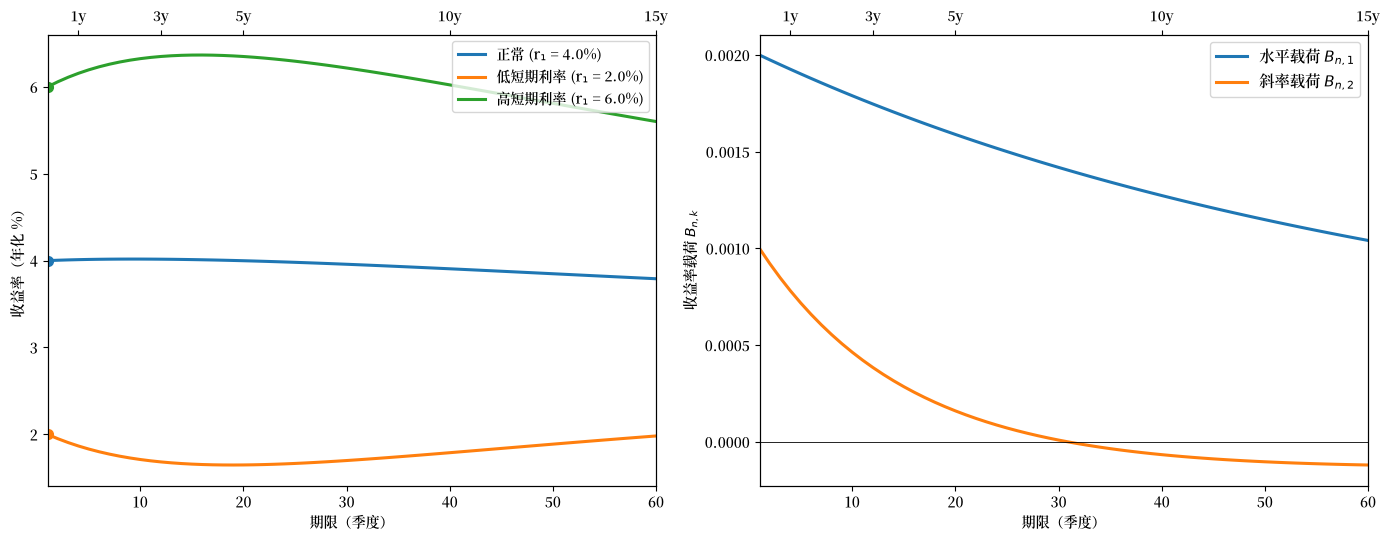

In [8]:
n_max_2f = 60
maturities_2f = np.arange(1, n_max_2f + 1)

states = {
    "正常":              np.array([0.0,   0.0]),
    "低短期利率":      np.array([-4.0,  3.0]),
    "高短期利率":     np.array([4.0,  -3.0]),
}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5.5))

for label, z in states.items():
    r_now = short_rate(model_2f, z) * 4 * 100
    y = compute_yields(model_2f, z, n_max_2f) * 4 * 100
    line, = ax1.plot(maturities_2f, y, lw=2.2,
                     label=f"{label} (r₁ = {r_now:.1f}%)")
    ax1.plot(1, y[0], 'o', color=line.get_color(), ms=7, zorder=5)

ax1.set_xlabel("期限（季度）")
ax1.set_ylabel("收益率（年化 %）")
ax1.legend(fontsize=10)
ax1.set_xlim(1, n_max_2f)

A_bar, B_bar = bond_coefficients(model_2f, n_max_2f)
ns = np.arange(1, n_max_2f + 1)
B_n = np.array([-B_bar[n] / n for n in ns])

ax2.plot(ns, B_n[:, 0], lw=2.2,
         label=r"水平载荷 $B_{n,1}$")
ax2.plot(ns, B_n[:, 1], lw=2.2,
         label=r"斜率载荷 $B_{n,2}$")
ax2.axhline(0, color='black', lw=0.6)
ax2.set_xlabel("期限（季度）")
ax2.set_ylabel(r"收益率载荷 $B_{n,k}$")
ax2.legend(fontsize=11)
ax2.set_xlim(1, n_max_2f)

for ax in (ax1, ax2):
    ax_top = ax.twiny()
    ax_top.set_xlim(ax.get_xlim())
    year_ticks = [4, 12, 20, 40, 60]
    ax_top.set_xticks(year_ticks)
    ax_top.set_xticklabels([f"{t/4:.0f}y" for t in year_ticks])

plt.tight_layout()
plt.show()

我们可以看到，水平因子在长期限处占主导地位。

## 风险溢价

仿射期限结构模型中的一个关键对象是**期限溢价**，即
长期债券相对于滚动短期债券的预期超额回报。

对于持有一期的 $(n+1)$ 期债券，冲击载荷为
$\alpha_n = C^\top \bar B_n$，因此 {eq}`eq_excess` 给出

$$
\log \mathbb{E}_t R_{t+1}^{(n+1)} - r_t \;=\; \bar B_n^\top C \lambda_t
$$

期限溢价等于债券冲击暴露 $\bar B_n^\top C$
与风险价格向量 $\lambda_t$ 的内积。

由于期限溢价等于 $\bar B_n^\top C \lambda_t$，其符号
取决于*当前*风险价格向量 $\lambda_t$，只要 $\lambda_z \neq 0$，
它就是状态依赖的。

为了更具体地看到这一点，考虑一个 $C\lambda_t$ 逐分量为负的状态
（例如，我们下面校准中的 $z_t = 0$）。

当 $\delta_1 > 0$ 时，正的冲击 $\varepsilon_{t+1}$ 会提高
短期利率并降低长期债券价格，因此债券冲击载荷
$\alpha_n = C^\top \bar B_n$ 为负。

那么负的 $C\lambda_t$ 意味着随机贴现因子
$m_{t+1}$ 对 $\varepsilon_{t+1}$ 正向载荷，即在利率上升
和债券价格下跌的状态下 SDF 较高。

这使得 $\text{Cov}_t(m_{t+1}, R_{t+1}^{(n+1)}) < 0$，因此长期债券
是有风险的，并带有正的期限溢价。

从代数上看，$\bar B_n < 0$ 和 $C\lambda_t < 0$ 结合
得到 $\bar B_n^\top C \lambda_t > 0$。

然而，在其他状态下，$\lambda_t$ 可能会改变符号（例如，在我们的双状态
校准的低利率状态下，第一个分量翻转），长期债券期限溢价
在较长期限处可能变为负值。

```{exercise}
:label: arp_ex5

通过计算 $(n+1)$ 期债券的单期持有回报并识别其冲击载荷，推导上面的期限溢价公式。

*提示：* 使用 $R_{t+1}^{(n+1)} = p_{t+1}(n)/p_t(n+1)$ 以及
$\log p_t(n) = \bar A_n + \bar B_n^\top z_t$，代入状态
动态 {eq}`eq_var`，并应用黎卡提方程
{eq}`eq_riccati_a`--{eq}`eq_riccati_b` 进行简化。
```

```{solution-start} arp_ex5
:class: dropdown
```

$(n+1)$ 期债券的单期持有回报为
$R_{t+1}^{(n+1)} = p_{t+1}(n)/p_t(n+1)$，因此

$$
\log R_{t+1}^{(n+1)} = \bar A_n + \bar B_n^\top z_{t+1} - \bar A_{n+1} - \bar B_{n+1}^\top z_t
$$

代入 {eq}`eq_var` 中的 $z_{t+1} = \mu + \phi z_t + C\varepsilon_{t+1}$：

$$
= \underbrace{(\bar A_n + \bar B_n^\top \mu - \bar A_{n+1})}_{\text{常数}}
  + \underbrace{(\bar B_n^\top \phi - \bar B_{n+1}^\top)}_{z_t \text{ 上的载荷}} z_t
  + \underbrace{\bar B_n^\top C}_{\text{冲击载荷}}\, \varepsilon_{t+1}
$$

现在我们使用黎卡提方程简化每一部分。

对于常数部分，{eq}`eq_riccati_a` 给出
$\bar A_{n+1} = \bar A_n + \bar B_n^\top(\mu - C\lambda_0) + \tfrac{1}{2}\bar B_n^\top CC^\top \bar B_n - \delta_0$，因此

$$
\bar A_n + \bar B_n^\top \mu - \bar A_{n+1}
  = \bar B_n^\top C\lambda_0 - \tfrac{1}{2}\bar B_n^\top CC^\top \bar B_n + \delta_0
$$

对于 $z_t$ 系数，{eq}`eq_riccati_b` 给出
$\bar B_{n+1}^\top = \bar B_n^\top(\phi - C\lambda_z) - \delta_1^\top$，因此

$$
\bar B_n^\top \phi - \bar B_{n+1}^\top = \bar B_n^\top C\lambda_z + \delta_1^\top
$$

结合各部分：

$$
\log R_{t+1}^{(n+1)}
  = \underbrace{(\delta_0 + \delta_1^\top z_t)}_{r_t}
  + \bar B_n^\top C\underbrace{(\lambda_0 + \lambda_z z_t)}_{\lambda_t}
  - \tfrac{1}{2}\bar B_n^\top CC^\top \bar B_n
  + \bar B_n^\top C\,\varepsilon_{t+1}
$$

写 $\alpha_n = C^\top \bar B_n$，这就取了通用回报形式 {eq}`eq_return`：

$$
\log R_{t+1}^{(n+1)}
  = \underbrace{(r_t + \alpha_n^\top \lambda_t)}_{\nu_t}
  - \tfrac{1}{2}\alpha_n^\top \alpha_n
  + \alpha_n^\top \varepsilon_{t+1}
$$

由于 $\mathbb{E}_t R_{t+1}^{(n+1)} = \exp(\nu_t)$，我们得到

$$
\log \mathbb{E}_t R_{t+1}^{(n+1)} - r_t = \alpha_n^\top \lambda_t = \bar B_n^\top C \lambda_t
$$

```{solution-end}
```

下图绘制了世界不同状态下跨期限的期限溢价，以及正常状态下水平因子和斜率因子对期限溢价的贡献

findfont: Failed to find font weight normal, now using 600.
findfont: Failed to find font weight normal, now using 600.


findfont: Failed to find font weight normal, now using 600.


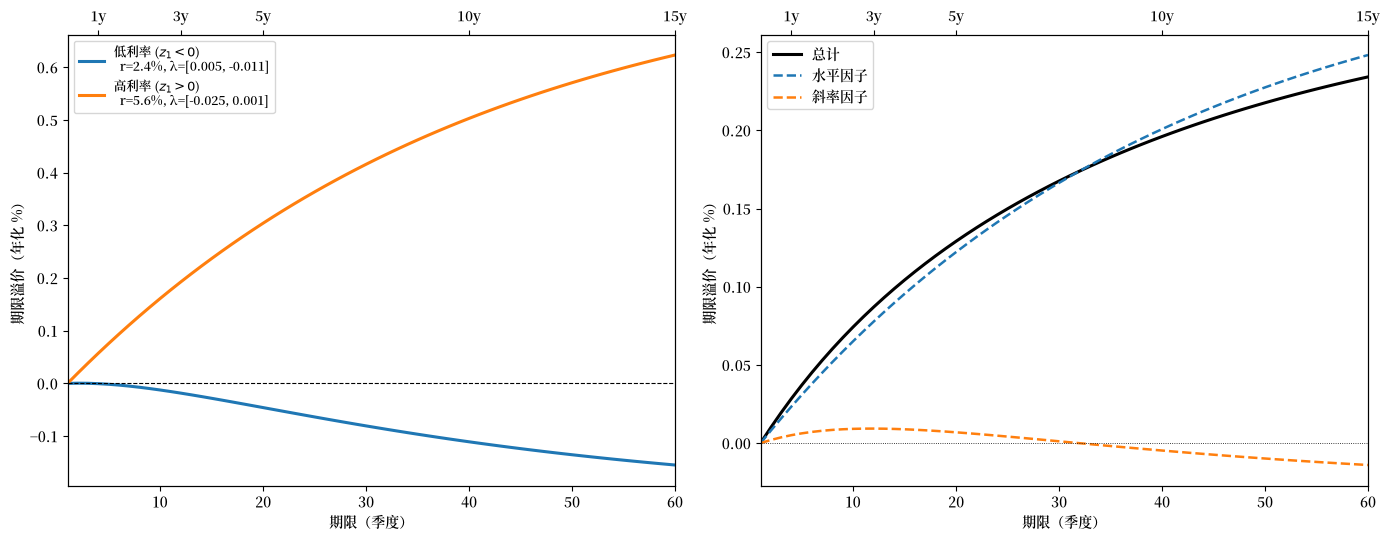

In [9]:
def term_premiums(model, z, n_max):
    """计算期限 1 到 n_max 的期限溢价。"""
    A_bar, B_bar = bond_coefficients(model, n_max + 1)
    λ_t = risk_prices(model, z)
    return np.array([B_bar[n-1] @ model.C @ λ_t
                     for n in range(1, n_max + 1)])

n_max_tp = 60
maturities_tp = np.arange(1, n_max_tp + 1)

z_states_tp = {
    "低利率 ($z_1 < 0$)":  np.array([-3.0, 2.0]),
    "高利率 ($z_1 > 0$)": np.array([3.0, -2.0]),
}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5.5))

for label, z in z_states_tp.items():
    tp = term_premiums(model_2f, z, n_max_tp) * 4 * 100
    r_now = short_rate(model_2f, z) * 4 * 100
    lam = risk_prices(model_2f, z)
    ax1.plot(maturities_tp, tp, lw=2.2,
             label=(f"{label}\n  r={r_now:.1f}%,"
                    f" λ=[{lam[0]:.3f}, {lam[1]:.3f}]"))

ax1.axhline(0, color="black", lw=0.8, ls="--")
ax1.set_xlabel("期限（季度）")
ax1.set_ylabel("期限溢价（年化 %）")
ax1.legend(fontsize=9)
ax1.set_xlim(1, n_max_tp)

z_decomp = np.array([0.0, 0.0])
A_bar_d, B_bar_d = bond_coefficients(model_2f, n_max_tp + 1)
λ_t = risk_prices(model_2f, z_decomp)
C_lam = model_2f.C @ λ_t

tp_level = np.array([B_bar_d[n-1, 0] * C_lam[0]
                      for n in range(1, n_max_tp + 1)]) * 4 * 100
tp_slope = np.array([B_bar_d[n-1, 1] * C_lam[1]
                      for n in range(1, n_max_tp + 1)]) * 4 * 100
tp_total = tp_level + tp_slope

ax2.plot(maturities_tp, tp_total, 'k-', lw=2.2, label="总计")
ax2.plot(maturities_tp, tp_level, lw=1.8, ls="--",
         label="水平因子")
ax2.plot(maturities_tp, tp_slope, lw=1.8, ls="--",
         label="斜率因子")
ax2.axhline(0, color="black", lw=0.6, ls=":")
ax2.set_xlabel("期限（季度）")
ax2.set_ylabel("期限溢价（年化 %）")
ax2.legend(fontsize=10)
ax2.set_xlim(1, n_max_tp)

for ax in (ax1, ax2):
    ax_top = ax.twiny()
    ax_top.set_xlim(ax.get_xlim())
    year_ticks = [4, 12, 20, 40, 60]
    ax_top.set_xticks(year_ticks)
    ax_top.set_xticklabels([f"{t/4:.0f}y" for t in year_ticks])

plt.tight_layout()
plt.show()

我们看到，在低利率状态下期限溢价在所有期限都为正，但在高利率状态下的较长期限处变为负值。

## 风险中性概率

我们回到 VAR 和短期利率方程
{eq}`eq_var`--{eq}`eq_shortrate`，为方便起见在此重复：

$$
z_{t+1} = \mu + \phi z_t + C\varepsilon_{t+1}, \qquad
r_t = \delta_0 + \delta_1^\top z_t
$$

其中 $\varepsilon_{t+1} \sim \mathcal{N}(0, I)$。

我们假设这一结构描述了数据生成机制。

金融经济学家称之为**物理测度** $P$，以区别于
我们现在描述的**风险中性测度** $Q$。

在物理测度下，给定 $z_t$ 的 $z_{t+1}$ 的条件分布
为 $\mathcal{N}(\mu + \phi z_t,\; CC^\top)$。

### 测度变换

利用 {eq}`eq_riskprices` 中的风险价格向量 $\lambda_t = \lambda_0 + \lambda_z z_t$，定义非负随机变量

```{math}
:label: eq_rn_ratio

\frac{\xi^Q_{t+1}}{\xi^Q_t}
  = \exp\!\left(-\tfrac{1}{2}\lambda_t^\top\lambda_t
                - \lambda_t^\top\varepsilon_{t+1}\right)
```

这是一个均值为 1 的对数正态随机变量，因此它是一个有效的
似然比，可用于扭曲 $z_{t+1}$ 的条件分布。

将物理条件分布乘以这个似然比
将其转换为**风险中性条件分布**

$$
z_{t+1} \mid z_t \;\overset{Q}{\sim}\;
  \mathcal{N}\!\bigl(\mu - C\lambda_0 + (\phi - C\lambda_z)z_t,\; CC^\top\bigr)
$$

换句话说，在 $Q$ 下状态遵循

$$
z_{t+1} = (\mu - C\lambda_0) + (\phi - C\lambda_z)\,z_t
         + C\varepsilon^Q_{t+1}
$$

其中在 $Q$ 下 $\varepsilon^Q_{t+1} \sim \mathcal{N}(0, I)$。

风险中性分布将条件均值从
$\mu + \phi z_t$ 扭曲为 $\mu - C\lambda_0 + (\phi - C\lambda_z)z_t$。

调整项 $-C\lambda_0$（常数）和 $-C\lambda_z$
（状态依赖）编码了定价方程
$\mathbb{E}^P_t m_{t+1} R_{j,t+1} = 1$ 如何针对
对风险 $\varepsilon_{t+1}$ 的暴露调整预期回报。

### 资产定价简述

设 $\mathbb{E}^P$ 表示在自然用于生成数据的物理测度下的期望。

我们的关键资产定价方程是
$\mathbb{E}^P_t m_{t+1} R_{j,t+1} = 1$ 对所有回报 $R_{j,t+1}$ 成立。

利用 {eq}`eq_rn_ratio`，我们可以将 SDF {eq}`eq_sdf` 表示为

$$
m_{t+1} = \frac{\xi^Q_{t+1}}{\xi^Q_t}\,\exp(-r_t)
$$

那么条件
$\mathbb{E}^P_t\bigl(\exp(-r_t)\,
\tfrac{\xi^Q_{t+1}}{\xi^Q_t}\, R_{j,t+1}\bigr) = 1$
等价于

```{math}
:label: eq_qpricing

\mathbb{E}^Q_t R_{j,t+1} = \exp(r_t)
```

*在风险中性测度下，所有资产的预期回报等于
无风险回报。*

### 通过风险中性定价进行验证

债券价格可以通过在 $Q$ 下以 $r_t$ 贴现来计算：

$$
p_t(n) = \mathbb{E}^Q_t  \left[\exp \left(-\sum_{s=0}^{n-1}r_{t+s}\right)\right]
$$

我们可以通过在风险中性 VAR 下迭代仿射
递归来验证这与 {eq}`eq_bondprice` 一致。

下面我们通过数值方法确认这一点

In [10]:
def bond_price_mc_Q(model, z0, n, n_sims=50_000, rng=None):
    """通过 Q 下的蒙特卡洛估计 p_t(n)。"""
    if rng is None:
        rng = np.random.default_rng(0)
    m = len(z0)
    Z = np.tile(z0, (n_sims, 1))
    disc = np.zeros(n_sims)
    for _ in range(n):
        disc += model.δ_0 + Z @ model.δ_1
        ε = rng.standard_normal((n_sims, m))
        Z = model.μ_rn + Z @ model.φ_rn.T + ε @ model.C.T
    return np.mean(np.exp(-disc))

z_test = np.array([0.01, 0.005])
p_analytic = bond_prices(model_2f, z_test, 40)

rng = np.random.default_rng(0)
maturities_check = [4, 12, 24, 40]
mc_prices = [bond_price_mc_Q(model_2f, z_test, n, n_sims=100_000, rng=rng)
             for n in maturities_check]

header = (f"{'期限':>10}  {'解析解':>12}"
          f"  {'蒙特卡洛':>12}  {'误差 (bps)':>12}")
print(header)
print("-" * 52)
for n, mc in zip(maturities_check, mc_prices):
    analytic = p_analytic[n - 1]
    error_bp = abs(analytic - mc) / analytic * 10_000
    print(f"{n:>10}  {analytic:>12.6f}  {mc:>12.6f}  {error_bp:>12.2f}")

        期限           解析解          蒙特卡洛      误差 (bps)
----------------------------------------------------
         4      0.960592      0.960571          0.23
        12      0.886276      0.886200          0.86
        24      0.787066      0.787580          6.53
        40      0.676314      0.676398          1.24


解析债券价格和蒙特卡洛债券价格紧密一致，验证了
黎卡提递归 {eq}`eq_riccati_a`–{eq}`eq_riccati_b`。

## 扭曲信念

{cite:t}`piazzesi2015trend` 汇集了调查证据，表明经济
专家的预测相对于物理测度存在系统性偏差。

### 主观测度

设 $\{z_t\}_{t=1}^T$ 为关于状态的观测记录，设
$\{\check z_{t+1}\}_{t=1}^T$ 为向前一期专家预测的记录。

设 $\check\mu, \check\phi$ 为以下回归中的回归系数

$$
\check z_{t+1} = \check\mu + \check\phi\, z_t + e_{t+1}
$$

其中残差 $e_{t+1}$ 均值为零，与 $z_t$ 正交，并
满足 $\mathbb{E}\,e_{t+1} e_{t+1}^\top = CC^\top$。

通过将 {eq}`eq_var` 中 $\mu, \phi$ 的估计与专家预测中
$\check\mu, \check\phi$ 的估计进行比较，{cite:t}`piazzesi2015trend`
推断出专家的信念存在系统性扭曲。

为了组织这一证据，设 $\kappa_t = \kappa_0 + \kappa_z z_t$ 并定义
似然比

```{math}
:label: eq_srat

\frac{\xi^S_{t+1}}{\xi^S_t}
  = \exp\!\left(-\tfrac{1}{2}\kappa_t^\top\kappa_t
                - \kappa_t^\top\varepsilon_{t+1}\right)
```

这是均值为 1 的对数正态，因此它是一个有效的似然比。

将 $z_{t+1}$ 的物理条件分布乘以这个
似然比，将其转换为专家的**主观条件
分布**

$$
z_{t+1} \mid z_t \;\overset{S}{\sim}\;
  \mathcal{N}\!\bigl(\mu - C\kappa_0 + (\phi - C\kappa_z)\,z_t,\; CC^\top\bigr)
$$

在专家的预测回归中，$\check\mu$ 估计
$\mu - C\kappa_0$，$\check\phi$ 估计 $\phi - C\kappa_z$。

{cite:t}`piazzesi2015trend` 发现，专家的行为就好像收益率曲线的水平和
斜率比物理测度下更持续：
$\check\phi$ 的特征值比 $\phi$ 更大。

### 扭曲信念下的定价

{cite:t}`piazzesi2015trend` 探讨了这样一个假设：一个持有这些扭曲信念的代表性
行为主体对资产定价，并使回报满足

$$
\mathbb{E}^S_t\bigl(m^\star_{t+1}\, R_{j,t+1}\bigr) = 1
$$

其中 $\mathbb{E}^S_t$ 是在主观
$S$ 测度下的条件期望，$m^\star_{t+1}$ 是持有这些信念的
行为主体的 SDF。

具体来说，行为主体的 SDF 为

$$
m^\star_{t+1} = \exp\!\left(-r^\star_t
  - \tfrac{1}{2}\lambda_t^{\star\top}\lambda^\star_t
  - \lambda_t^{\star\top}\varepsilon_{t+1}\right)
$$

其中 $r^\star_t$ 是短期利率，$\lambda^\star_t$ 是行为主体的
风险价格向量。

使用 {eq}`eq_srat` 转换到物理测度，主观
定价方程变为

$$
\mathbb{E}^P_t\!\left[
  \exp\!\left(-r^\star_t
    - \tfrac{1}{2}\lambda_t^{\star\top}\lambda^\star_t
    - \lambda_t^{\star\top}\varepsilon_{t+1}
  \right)
  \exp\!\left(
    - \tfrac{1}{2}\kappa_t^\top\kappa_t
    - \kappa_t^\top\varepsilon_{t+1}
  \right)
  R_{j,t+1}
\right] = 1
$$

合并两个指数得到

$$
\mathbb{E}^P_t\!\left[
  \exp\!\left(-r_t
    - \tfrac{1}{2}(\lambda^\star_t + \kappa_t)^\top(\lambda^\star_t + \kappa_t)
    - (\lambda^\star_t + \kappa_t)^\top\varepsilon_{t+1}
  \right) R_{j,t+1}
\right] = 1
$$

其中 $r_t = r^\star_t - \lambda_t^{\star\top}\kappa_t$。

将其与理性预期计量经济学家的定价
方程进行比较

$$
\mathbb{E}^P_t\!\left[
  \exp\!\left(-r_t
    - \tfrac{1}{2}\lambda_t^\top\lambda_t
    - \lambda_t^\top\varepsilon_{t+1}
  \right) R_{j,t+1}
\right] = 1
$$

我们看到，计量经济学家解释为 $\lambda_t$ 的实际上是
$\lambda^\star_t + \kappa_t$。

因为计量经济学家的估计部分反映了主观信念中的
系统性扭曲，在这种校准中它们可能高估了代表性
行为主体真实的风险价格 $\lambda^\star_t$。

下面我们构造一个数值例子来说明这一点。

我们保持与上面相同的物理状态动态和短期利率设定，但选择一个单独的真实风险价格过程 $(\lambda_t^\star)$ 和一个扭曲信念计量经济学家过程 $(\hat\lambda_t)$ 来说明这一分解。

然后我们设定主观参数 $\check\mu, \check\phi$ 以匹配
{cite:t}`piazzesi2015trend` 中的证据，即专家的行为就好像收益率曲线的水平和斜率比物理测度下更持续。

具体来说，我们使用

$$
\check\phi = \begin{pmatrix} 0.985 & -0.025 \\ 0.00 & 0.94 \end{pmatrix}
$$

In [11]:
φ_P = φ_2.copy()
μ_P = μ_2.copy()

# 主观参数：专家认为因子更持续
φ_S = np.array([[0.985, -0.025], [0.00, 0.94]])
μ_S = np.array([0.005, 0.0])

κ_z = np.linalg.solve(C_2, φ_P - φ_S)
κ_0 = np.linalg.solve(C_2, μ_P - μ_S)

λ_star_0 = np.array([-0.03, -0.015])
λ_star_z = np.array([[-0.006, 0.0], [0.0, -0.004]])

λ_hat_0 = λ_star_0 + κ_0
λ_hat_z = λ_star_z + κ_z

findfont: Failed to find font weight normal, now using 600.
findfont: Failed to find font weight normal, now using 600.


findfont: Failed to find font weight normal, now using 600.


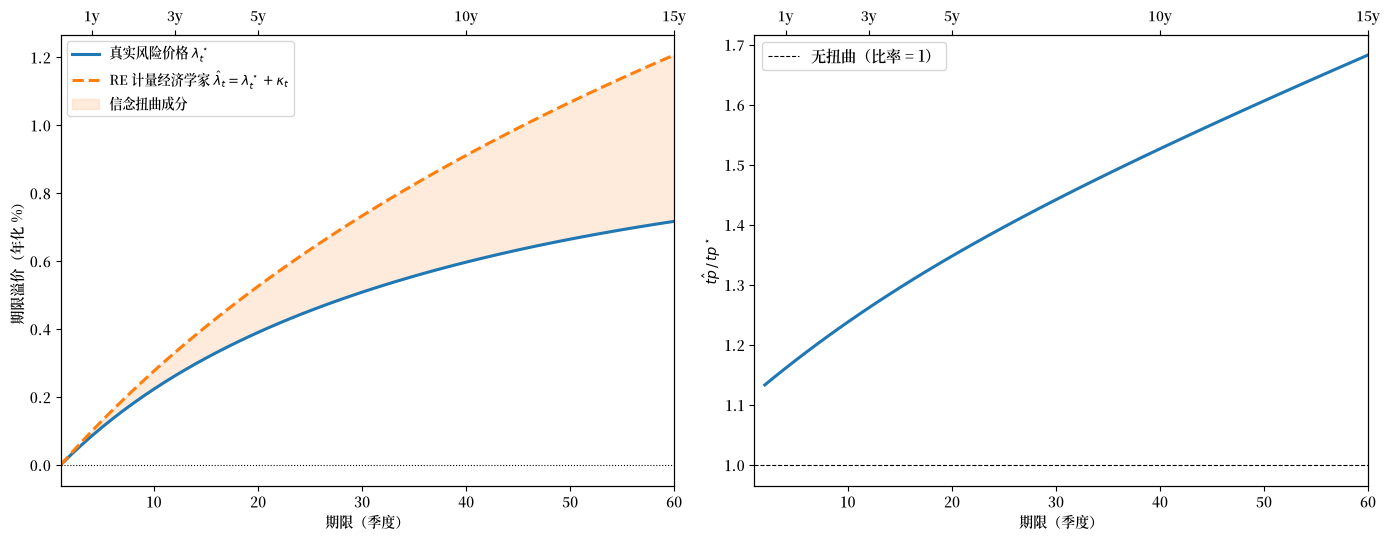

In [12]:
model_true = create_affine_model(
    μ_2, φ_2, C_2, δ_0_2, δ_1_2, λ_star_0, λ_star_z)
model_econ = create_affine_model(
    μ_2, φ_2, C_2, δ_0_2, δ_1_2, λ_hat_0, λ_hat_z)

z_ref = np.array([0.0, 0.0])
n_max_db = 60
maturities_db = np.arange(1, n_max_db + 1)

tp_true = term_premiums(model_true, z_ref, n_max_db) * 4 * 100
tp_econ = term_premiums(model_econ, z_ref, n_max_db) * 4 * 100

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5.5))

ax1.plot(maturities_db, tp_true, lw=2.2,
         label=r"真实风险价格 $\lambda^\star_t$")
line_econ, = ax1.plot(maturities_db, tp_econ, lw=2.2, ls="--",
         label=(r"RE 计量经济学家"
                r" $\hat\lambda_t = \lambda^\star_t + \kappa_t$"))
ax1.fill_between(maturities_db, tp_true, tp_econ,
                 alpha=0.15, color=line_econ.get_color(),
                 label="信念扭曲成分")
ax1.axhline(0, color="black", lw=0.8, ls=":")
ax1.set_xlabel("期限（季度）")
ax1.set_ylabel("期限溢价（年化 %）")
ax1.legend(fontsize=9.5)
ax1.set_xlim(1, n_max_db)

mask = np.abs(tp_true) > 1e-8
ratio = np.full_like(tp_true, np.nan)
ratio[mask] = tp_econ[mask] / tp_true[mask]

ax2.plot(maturities_db[mask], ratio[mask], lw=2.2)
ax2.axhline(1, color="black", lw=0.8, ls="--",
            label="无扭曲（比率 = 1）")
ax2.set_xlabel("期限（季度）")
ax2.set_ylabel(r"$\hat{tp}\, /\, tp^\star$")
ax2.legend(fontsize=11)
ax2.set_xlim(1, n_max_db)

for ax in (ax1, ax2):
    ax_top = ax.twiny()
    ax_top.set_xlim(ax.get_xlim())
    year_ticks = [4, 12, 20, 40, 60]
    ax_top.set_xticks(year_ticks)
    ax_top.set_xticklabels([f"{t/4:.0f}y" for t in year_ticks])

plt.tight_layout()
plt.show()

当专家信念过度持续（$\check\phi$ 的特征值比 $\phi$
更大）时，理性预期计量经济学家将过多的
观测到的风险溢价归因于风险厌恶。

将信念扭曲与真正的风险价格区分开来需要额外的
数据，例如 {cite:t}`piazzesi2015trend` 使用的调查预测。

我们的 {doc}`advanced:risk_aversion_or_mistaken_beliefs` 讲座
更深入地探讨了这种混淆。

## 结束语

随机贴现因子的仿射模型为研究资产价格提供了一个灵活且易于处理的
框架。

关键特征是：

1. **解析易处理性：** 债券价格是 $z_t$ 的指数仿射；
   预期回报可清晰地分解为短期利率加上一个风险价格×暴露内积。
2. **实证灵活性：** 自由参数 $(\mu, \phi, C, \delta_0, \delta_1, \lambda_0, \lambda_z)$
   可以通过最大似然估计（{doc}`卡尔曼滤波 <kalman>` 章节描述了
   相关方法），而无需施加来自完整一般均衡模型的约束。
3. **多重风险：** 向量结构可容纳许多风险来源（货币
   政策、实际活动、波动率等）。
4. **信念扭曲：** 该框架通过对物理测度的似然比扭曲，自然地容纳
   非理性信念，如 {cite:t}`piazzesi2015trend` 所示。

该模型还直接连接到 {doc}`advanced:doubts_or_variability` 中研究的
Hansen–Jagannathan 边界，以及 {cite:t}`Ljungqvist2012` 其他章节中描述的
随机贴现因子的稳健控制解释。

关于对本处连续状态框架进行补充的资产定价有限状态方法，
参见 {doc}`资产定价：有限状态模型 <markov_asset>`。